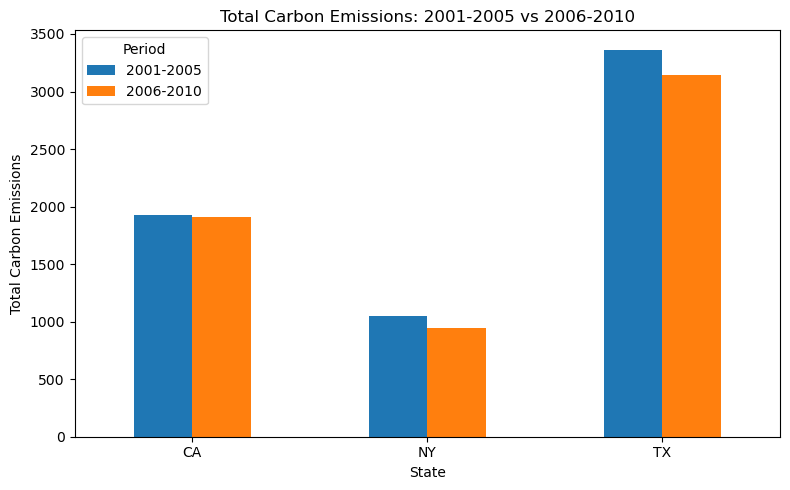

In [2]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("/Users/jasonbao/Downloads/state_total_co2_2001_2010.csv")

df["Period"] = df["Year"].apply(
    lambda y: "2001-2005" if 2001 <= y <= 2005 else "2006-2010"
)

period_summary = (
    df.groupby(["State", "Period"])["Total carbon emissions"]
    .sum()
    .unstack()
)

# Plot
period_summary.plot(kind="bar", figsize=(8, 5))

plt.title("Total Carbon Emissions: 2001-2005 vs 2006-2010")
plt.xlabel("State")
plt.ylabel("Total Carbon Emissions")
plt.xticks(rotation=0)
plt.legend(title="Period")
plt.tight_layout()
plt.show()

From this bar plot, we can see that all three states have total carbon emission decrease. Specifically, Texas and New York decrease with a more obvious scale. For California, carbon emissions did change, but in a trivial scale. We interpret this difference as a variation of states' carbon-related energy reliability. For example, Texas is highly reliant on carbon energy. After imposing a policy, it would be easy to observe a shift of energy composition and thus a big difference. This change will study further in the following parts

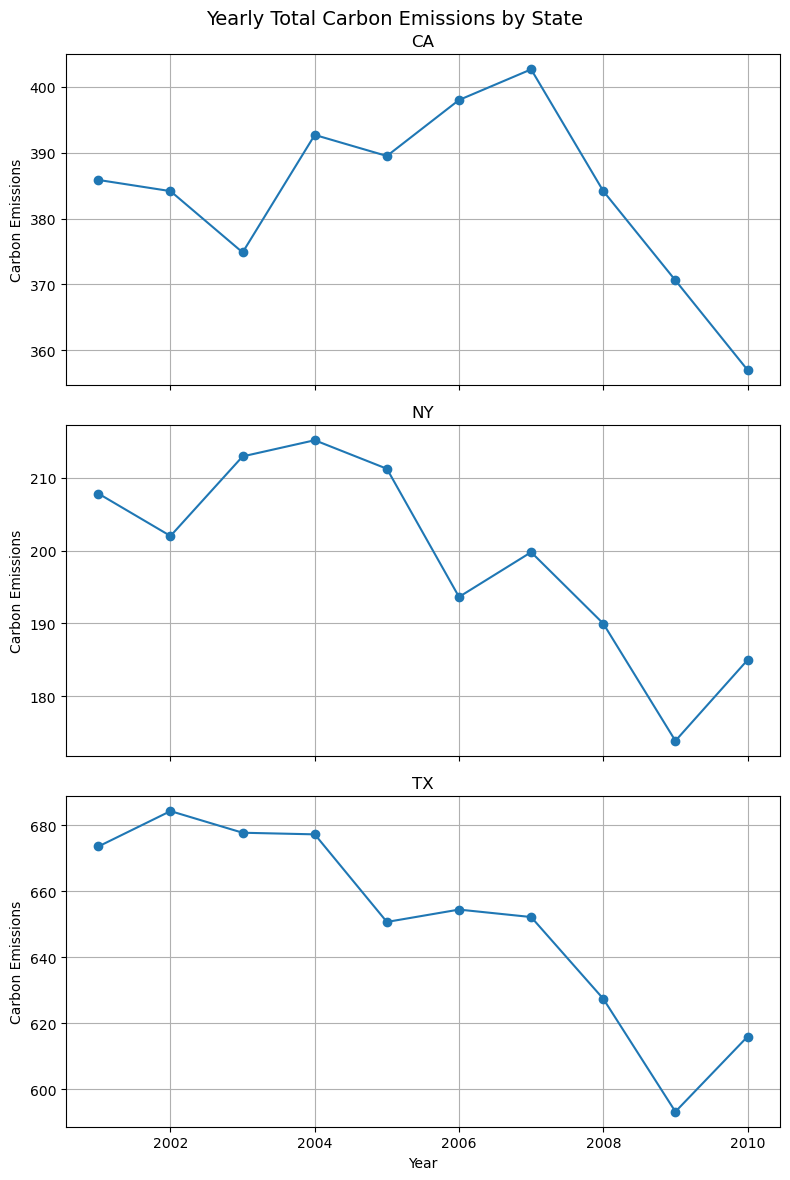

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(8, 12), sharex=True)

states = df["State"].unique()
for ax, state in zip(axes, states):
    state_data = df[df["State"] == state]
    
    ax.plot(
        state_data["Year"],
        state_data["Total carbon emissions"],
        marker="o"
    )
    
    ax.set_title(f"{state}")
    ax.set_ylabel("Carbon Emissions")
    ax.grid(True)

axes[-1].set_xlabel("Year")
plt.suptitle("Yearly Total Carbon Emissions by State", fontsize=14)
plt.tight_layout()
plt.show()

From each year's carbon emission line chart, we observe a significant drop in carbon emission in all states, indicating the energy policy kicks off rapidly.

### Next Step

Here we will dive in these three states further by looking at their energy usage decomposition. This section includes specific analysis on data patterns, and we will specify a state to analyze. From previous work, we see that texas has a large decrease in Carbon-based energy usage.

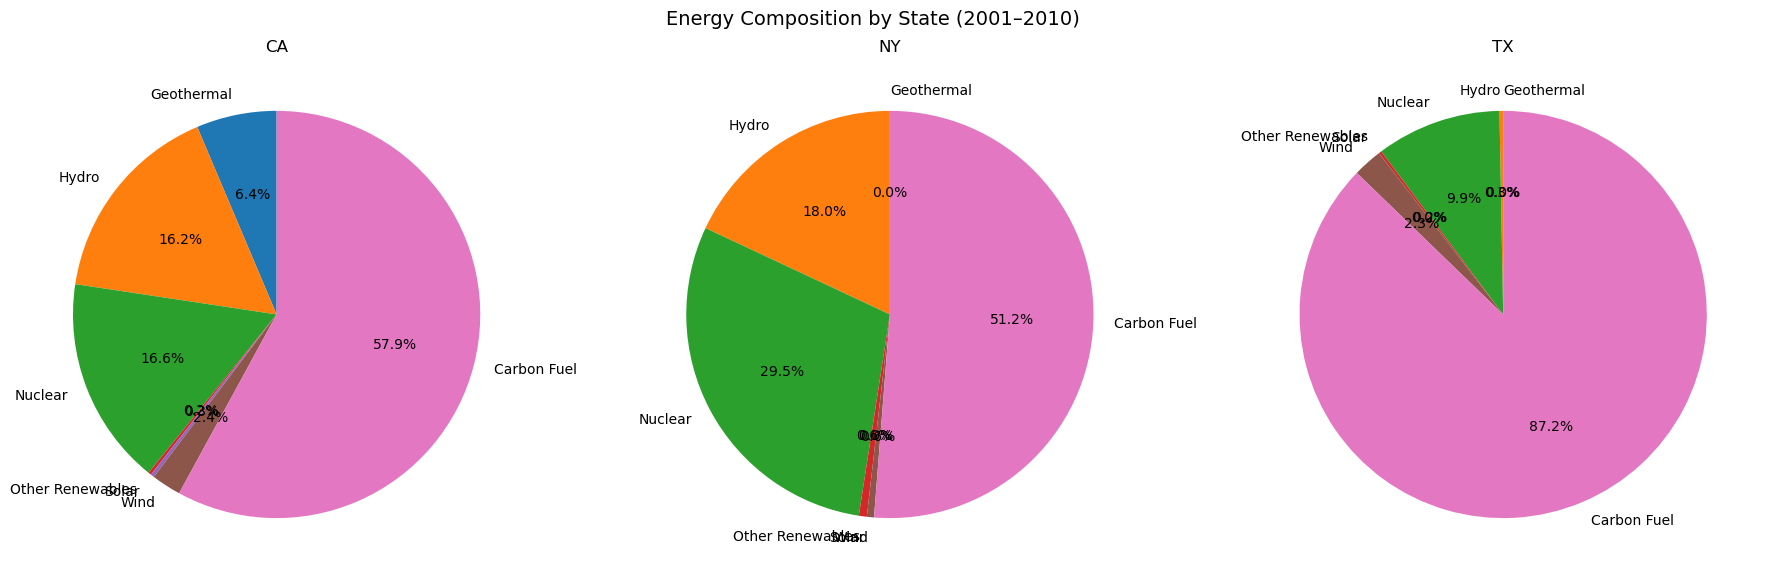

In [10]:

df = pd.read_csv("/Users/jasonbao/Downloads/all_fuels_clean1.csv")

fuel_cols = [
    "Geothermal",
    "Hydroelectric Conventional",
    "Nuclear",
    "Other_Renewables",
    "Solar Thermal and Photovoltaic",
    "Wind",
    "carbon_related_fuel"
]

short_labels = [
    "Geothermal",
    "Hydro",
    "Nuclear",
    "Other Renewables",
    "Solar",
    "Wind",
    "Carbon Fuel"
]

states = df["State"].unique()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, state in zip(axes, states):
    state_data = df[df["State"] == state]
    fuel_totals = state_data[fuel_cols].sum()

    ax.pie(
        fuel_totals,
        labels=short_labels,
        autopct="%1.1f%%",
        startangle=90
    )
    ax.set_title(f"{state}")

plt.suptitle("Energy Composition by State (2001–2010)", fontsize=14)
plt.tight_layout()
plt.show()

Specifically, Texas' carbon fuel is a high-weight sector, taking 87.2% of their total energy. Whereas from our hypothesis, non-carbon-base energy section will expand because of the energy policy. We will analyze this using different graphs by matplotlib, seaborn or plotnine

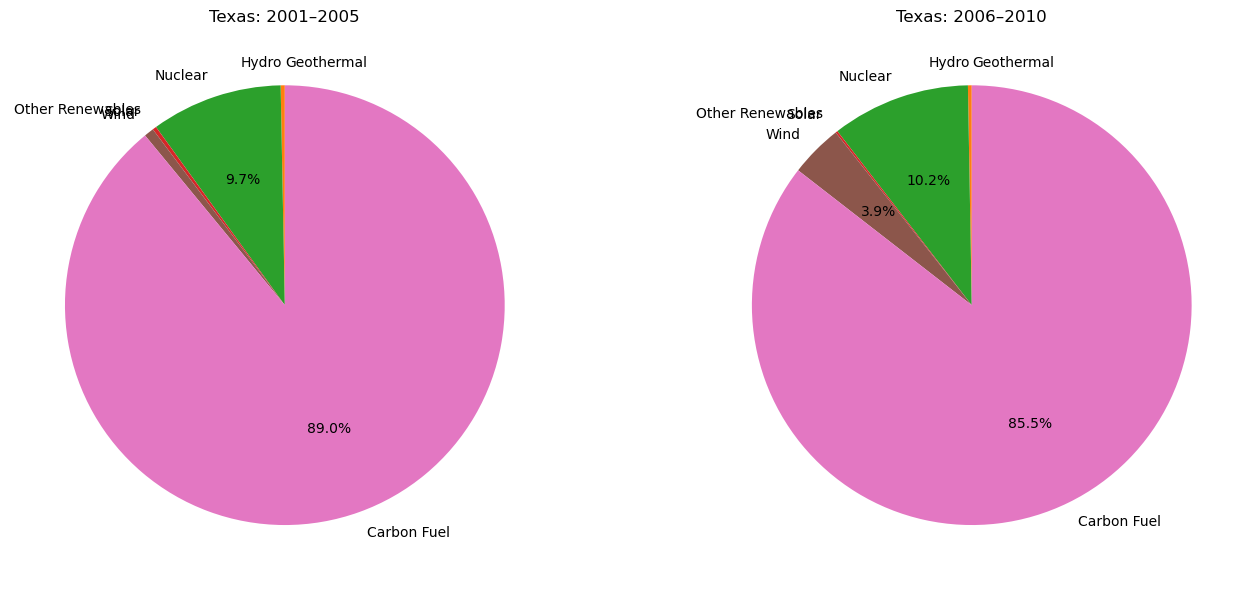

In [11]:

tx = df[df["State"] == "TX"].copy()

fuel_cols = [
    "Geothermal",
    "Hydroelectric Conventional",
    "Nuclear",
    "Other_Renewables",
    "Solar Thermal and Photovoltaic",
    "Wind",
    "carbon_related_fuel"
]

labels = [
    "Geothermal",
    "Hydro",
    "Nuclear",
    "Other Renewables",
    "Solar",
    "Wind",
    "Carbon Fuel"
]

tx_2001_2005 = tx[(tx["Year"] >= 2001) & (tx["Year"] <= 2005)][fuel_cols].sum()
tx_2006_2010 = tx[(tx["Year"] >= 2006) & (tx["Year"] <= 2010)][fuel_cols].sum()

def pct_fmt(pct):
    return f"{pct:.1f}%" if pct >= 2 else ""

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].pie(tx_2001_2005, labels=labels, autopct=pct_fmt, startangle=90)
axes[0].set_title("Texas: 2001–2005")

axes[1].pie(tx_2006_2010, labels=labels, autopct=pct_fmt, startangle=90)
axes[1].set_title("Texas: 2006–2010")

plt.tight_layout()
plt.show()

By some easy calculations, we can see that renewable energy increase by 3.5%. This, compared with the original 11% base, is a 32% percentage increase for non-carbon fuel sector. Therefore, this is a strong evidence to prove that the energy policy functioned well in 2005.

In [14]:

tx_emissions = emissions[emissions["State"] == "TX"].copy()
tx_fuels = fuels[fuels["State"] == "TX"].copy()


tx = pd.merge(tx_emissions, tx_fuels, on=["State", "Year"], how="inner")

# Response variable: total carbon emissions
y = tx["Total carbon emissions"]

# Predictor variables
X = tx[
    [
        "carbon_related_fuel",
        "Geothermal",
        "Hydroelectric Conventional",
        "Nuclear",
        "Other_Renewables",
        "Solar Thermal and Photovoltaic",
        "Wind",
    ]
]

# Add intercept
X = sm.add_constant(X)

# Fit OLS regression
model = sm.OLS(y, X).fit()

# Print results
print(model.summary())

                              OLS Regression Results                              
Dep. Variable:     Total carbon emissions   R-squared:                       0.929
Model:                                OLS   Adj. R-squared:                  0.787
Method:                     Least Squares   F-statistic:                     6.551
Date:                    Tue, 10 Mar 2026   Prob (F-statistic):             0.0758
Time:                            02:31:14   Log-Likelihood:                -34.475
No. Observations:                      10   AIC:                             82.95
Df Residuals:                           3   BIC:                             85.07
Df Model:                               6                                         
Covariance Type:                nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------

/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=10
  res = hypotest_fun_out(*samples, **kwds)


In [15]:
coef_table = pd.DataFrame({
    "Variable": model.params.index,
    "Coefficient": model.params.values,
    "P-value": model.pvalues.values
})

print(coef_table)

                         Variable   Coefficient   P-value
0                           const  6.207655e+02  0.070300
1             carbon_related_fuel  2.776611e-04  0.707661
2                      Geothermal  6.607554e-09  0.070292
3      Hydroelectric Conventional -1.565150e-04  0.993747
4                         Nuclear -1.037876e-03  0.690094
5                Other_Renewables  5.649582e-03  0.673244
6  Solar Thermal and Photovoltaic  4.424798e+00  0.197429
7                            Wind -3.620565e-03  0.051889


The 7-variable OLS regression for Texas suggests that the energy variables collectively explain a large portion of the variation in total carbon emissions (R^2= 0.929), but the overall model is only marginally significant (p=0.0758). Among the predictors, wind energy shows the strongest relationship with emissions, with a negative coefficient and borderline significance (p=0.052), suggesting that greater wind usage may be associated with lower carbon emissions. However, none of the predictors are statistically significant at the 5% level. Because the model uses many predictors with only 10 yearly observations, and because the output indicates severe multicollinearity, the individual coefficient estimates should be interpreted cautiously.

In [17]:
tx_emissions = emissions[emissions["State"] == "TX"].copy()
tx_fuels = fuels[fuels["State"] == "TX"].copy()

tx = pd.merge(tx_emissions, tx_fuels, on=["State", "Year"], how="inner")

y = tx["Total carbon emissions"]

X_small = tx[
    [
        "carbon_related_fuel",
        "Wind",
        "Solar Thermal and Photovoltaic",
        "Other_Renewables",
    ]
]

X_small = sm.add_constant(X_small)

model_small = sm.OLS(y, X_small).fit()
print(model_small.summary())

                              OLS Regression Results                              
Dep. Variable:     Total carbon emissions   R-squared:                       0.924
Model:                                OLS   Adj. R-squared:                  0.864
Method:                     Least Squares   F-statistic:                     15.25
Date:                    Tue, 10 Mar 2026   Prob (F-statistic):            0.00523
Time:                            02:36:31   Log-Likelihood:                -34.804
No. Observations:                      10   AIC:                             79.61
Df Residuals:                           5   BIC:                             81.12
Df Model:                               4                                         
Covariance Type:                nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------

/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=10
  res = hypotest_fun_out(*samples, **kwds)


The reduced 4-variable OLS model provides a better fit than the full 7-variable model. It explains a large proportion of the variation in Texas total carbon emissions (R^2 =0.924, adjusted R^2 =0.864) and is statistically significant overall (F-test p = 0.00523). Among the predictors, wind energy has a statistically significant negative coefficient (p = 0.003), suggesting that greater wind usage is associated with lower carbon emissions in Texas, holding the other included variables fixed. Solar energy has a positive coefficient and is marginally significant at the 10% level (p = 0.063), while carbon-related fuel and other renewables are not statistically significant in this model. Although the reduced model is more stable and interpretable, the small sample size and remaining multicollinearity suggest that results should still be interpreted with caution.

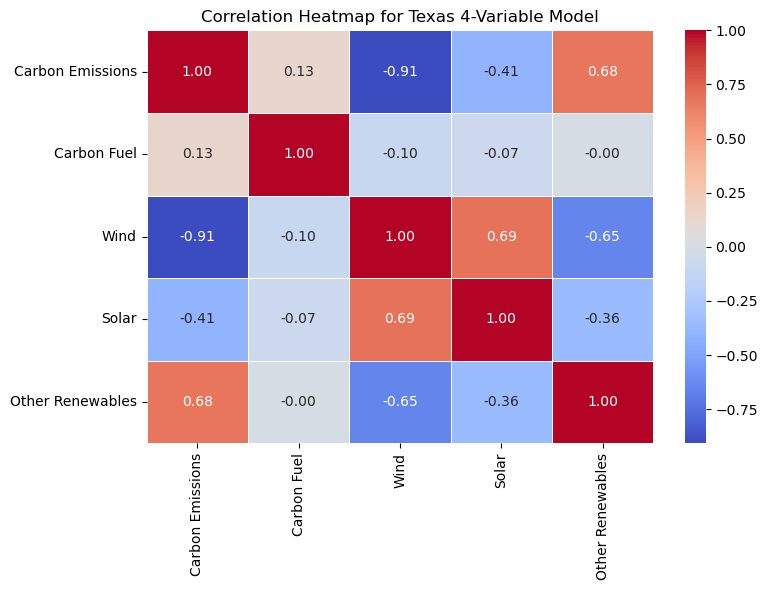

In [19]:
import seaborn as sns
tx = pd.merge(tx_emissions, tx_fuels, on=["State", "Year"], how="inner")

plot_df = tx[
    [
        "Total carbon emissions",
        "carbon_related_fuel",
        "Wind",
        "Solar Thermal and Photovoltaic",
        "Other_Renewables"
    ]
].copy()

# Shorter labels for cleaner plot
plot_df.columns = [
    "Carbon Emissions",
    "Carbon Fuel",
    "Wind",
    "Solar",
    "Other Renewables"
]

# Correlation matrix
corr = plot_df.corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)

plt.title("Correlation Heatmap for Texas 4-Variable Model")
plt.tight_layout()
plt.show()

The heatmap shows that wind has the strongest relationship with Texas total carbon emissions, with a very strong negative correlation of -0.91. This supports the regression result, where wind was also the most statistically important predictor and had a negative coefficient. Other renewables show a moderately positive correlation with emissions (0.68), while solar has a moderate negative correlation (-0.41). However, wind and solar are themselves positively correlated (0.69), and wind is negatively correlated with other renewables (-0.65), indicating that some multicollinearity remains even in the reduced model. Carbon-related fuel has only a weak correlation with emissions (0.13), which is consistent with its lack of significance in the regression.

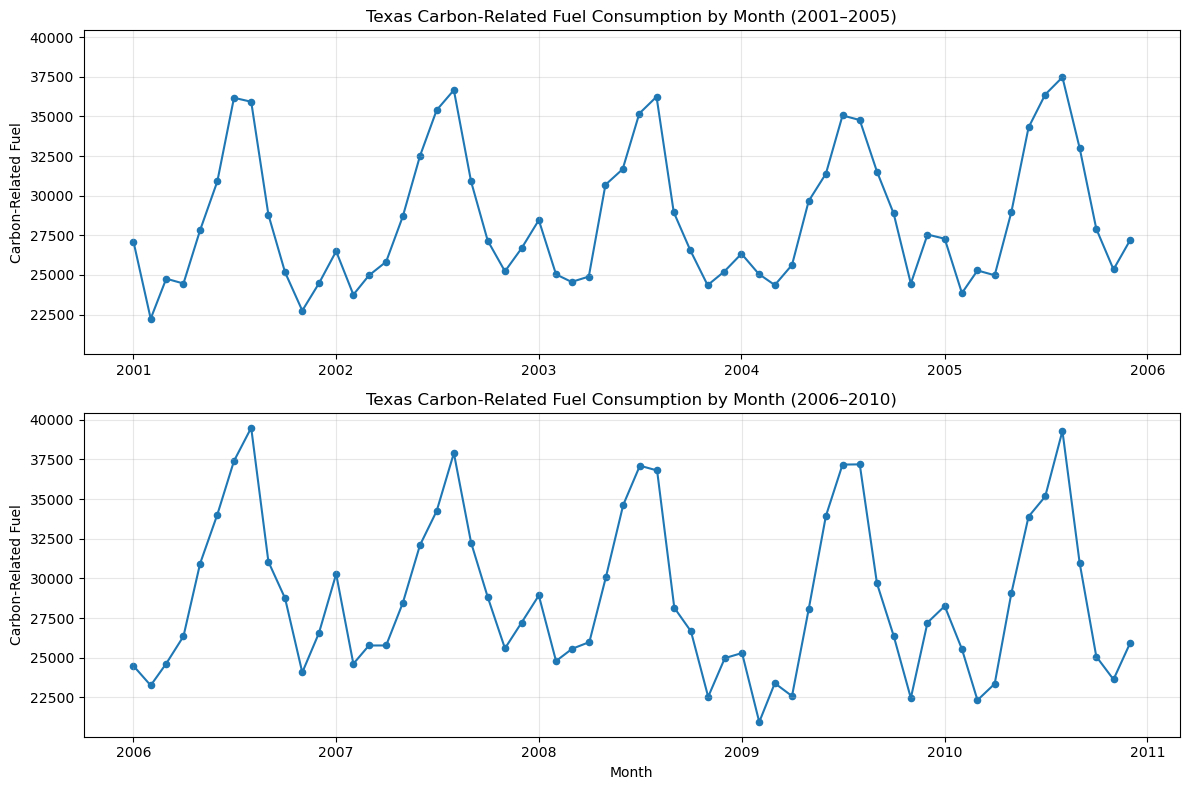

In [14]:
df = pd.read_csv("TX_fuels_clean1.csv")

# Keep only Texas and needed columns
df = df[df["STATE"] == "TX"][["YEAR", "MONTH", "carbon_related_fuel"]].copy()

# Convert to integers
df["YEAR"] = df["YEAR"].astype(int)
df["MONTH"] = df["MONTH"].astype(int)

# Create date column
df["Date"] = pd.to_datetime(dict(year=df["YEAR"], month=df["MONTH"], day=1))

# Split periods
df1 = df[(df["YEAR"] >= 2001) & (df["YEAR"] <= 2005)].sort_values("Date")
df2 = df[(df["YEAR"] >= 2006) & (df["YEAR"] <= 2010)].sort_values("Date")

# Plot
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharey=True)

axes[0].plot(df1["Date"], df1["carbon_related_fuel"])
axes[0].scatter(df1["Date"], df1["carbon_related_fuel"],s=20)
axes[0].set_title("Texas Carbon-Related Fuel Consumption by Month (2001–2005)")
axes[0].set_ylabel("Carbon-Related Fuel")
axes[0].grid(True, alpha=0.3)

axes[1].plot(df2["Date"], df2["carbon_related_fuel"])
axes[1].scatter(df2["Date"], df2["carbon_related_fuel"],s=20)
axes[1].set_title("Texas Carbon-Related Fuel Consumption by Month (2006–2010)")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Carbon-Related Fuel")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

This is a monthly time series because the data are ordered over time, and the plot shows a clear seasonal pattern rather than random variation. In both 2001–2005 and 2006–2010, carbon-related fuel consumption rises and falls in a similar yearly cycle, with repeated peaks and dips, while the overall level stays fairly stable without a strong long-term upward or downward trend. The later period seems slightly more variable, but the main feature of the graph is its regular seasonal behavior. 

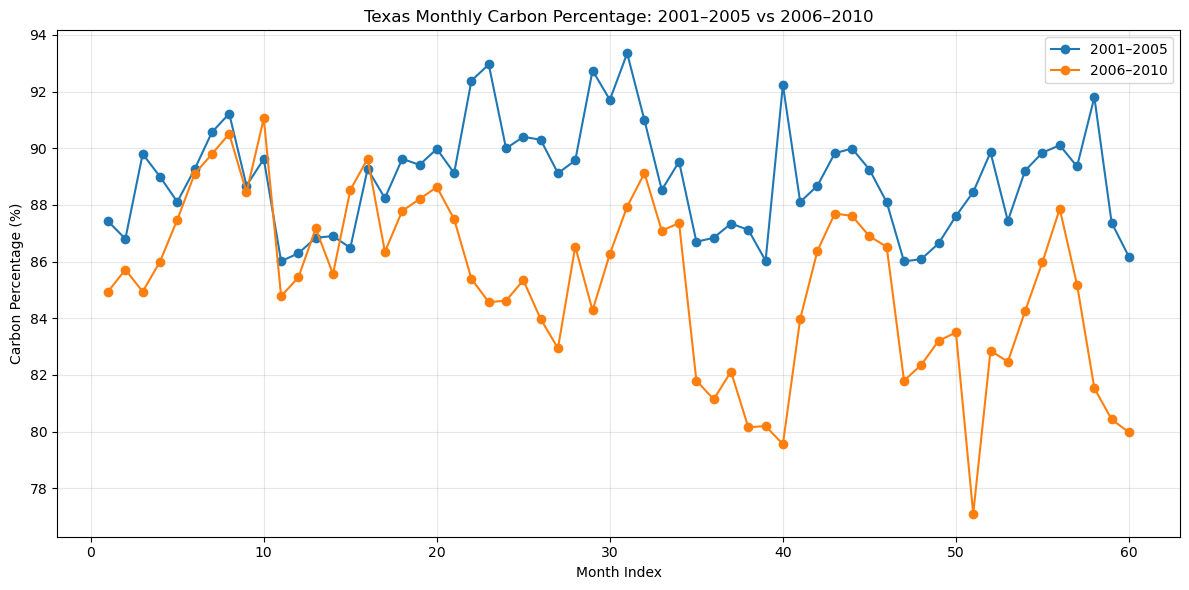

In [18]:


df = pd.read_csv("TX_fuels_clean1.csv")
# Convert types
df = df[df["STATE"] == "TX"].copy()

# Convert types
df["YEAR"] = df["YEAR"].astype(int)
df["MONTH"] = df["MONTH"].astype(int)

df["YEAR"] = df["YEAR"].astype(int)
df["MONTH"] = df["MONTH"].astype(int)

df["carbon%"] = (df["carbon_related_fuel"] / df["Total"]) * 100

# Create date column
df["Date"] = pd.to_datetime(dict(year=df["YEAR"], month=df["MONTH"], day=1))
# Split periods
df1 = df[(df["YEAR"] >= 2001) & (df["YEAR"] <= 2005)].sort_values("Date")
df2 = df[(df["YEAR"] >= 2006) & (df["YEAR"] <= 2010)].sort_values("Date")

# Use month index within each period so the two periods align on one graph
df1["Month_Index"] = range(1, len(df1) + 1)
df2["Month_Index"] = range(1, len(df2) + 1)

# Plot both on one graph
plt.figure(figsize=(12, 6))

plt.plot(df1["Month_Index"], df1["carbon%"], marker="o", label="2001–2005")
plt.plot(df2["Month_Index"], df2["carbon%"], marker="o", label="2006–2010")

plt.xlabel("Month Index")
plt.ylabel("Carbon Percentage (%)")
plt.title("Texas Monthly Carbon Percentage: 2001–2005 vs 2006–2010")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

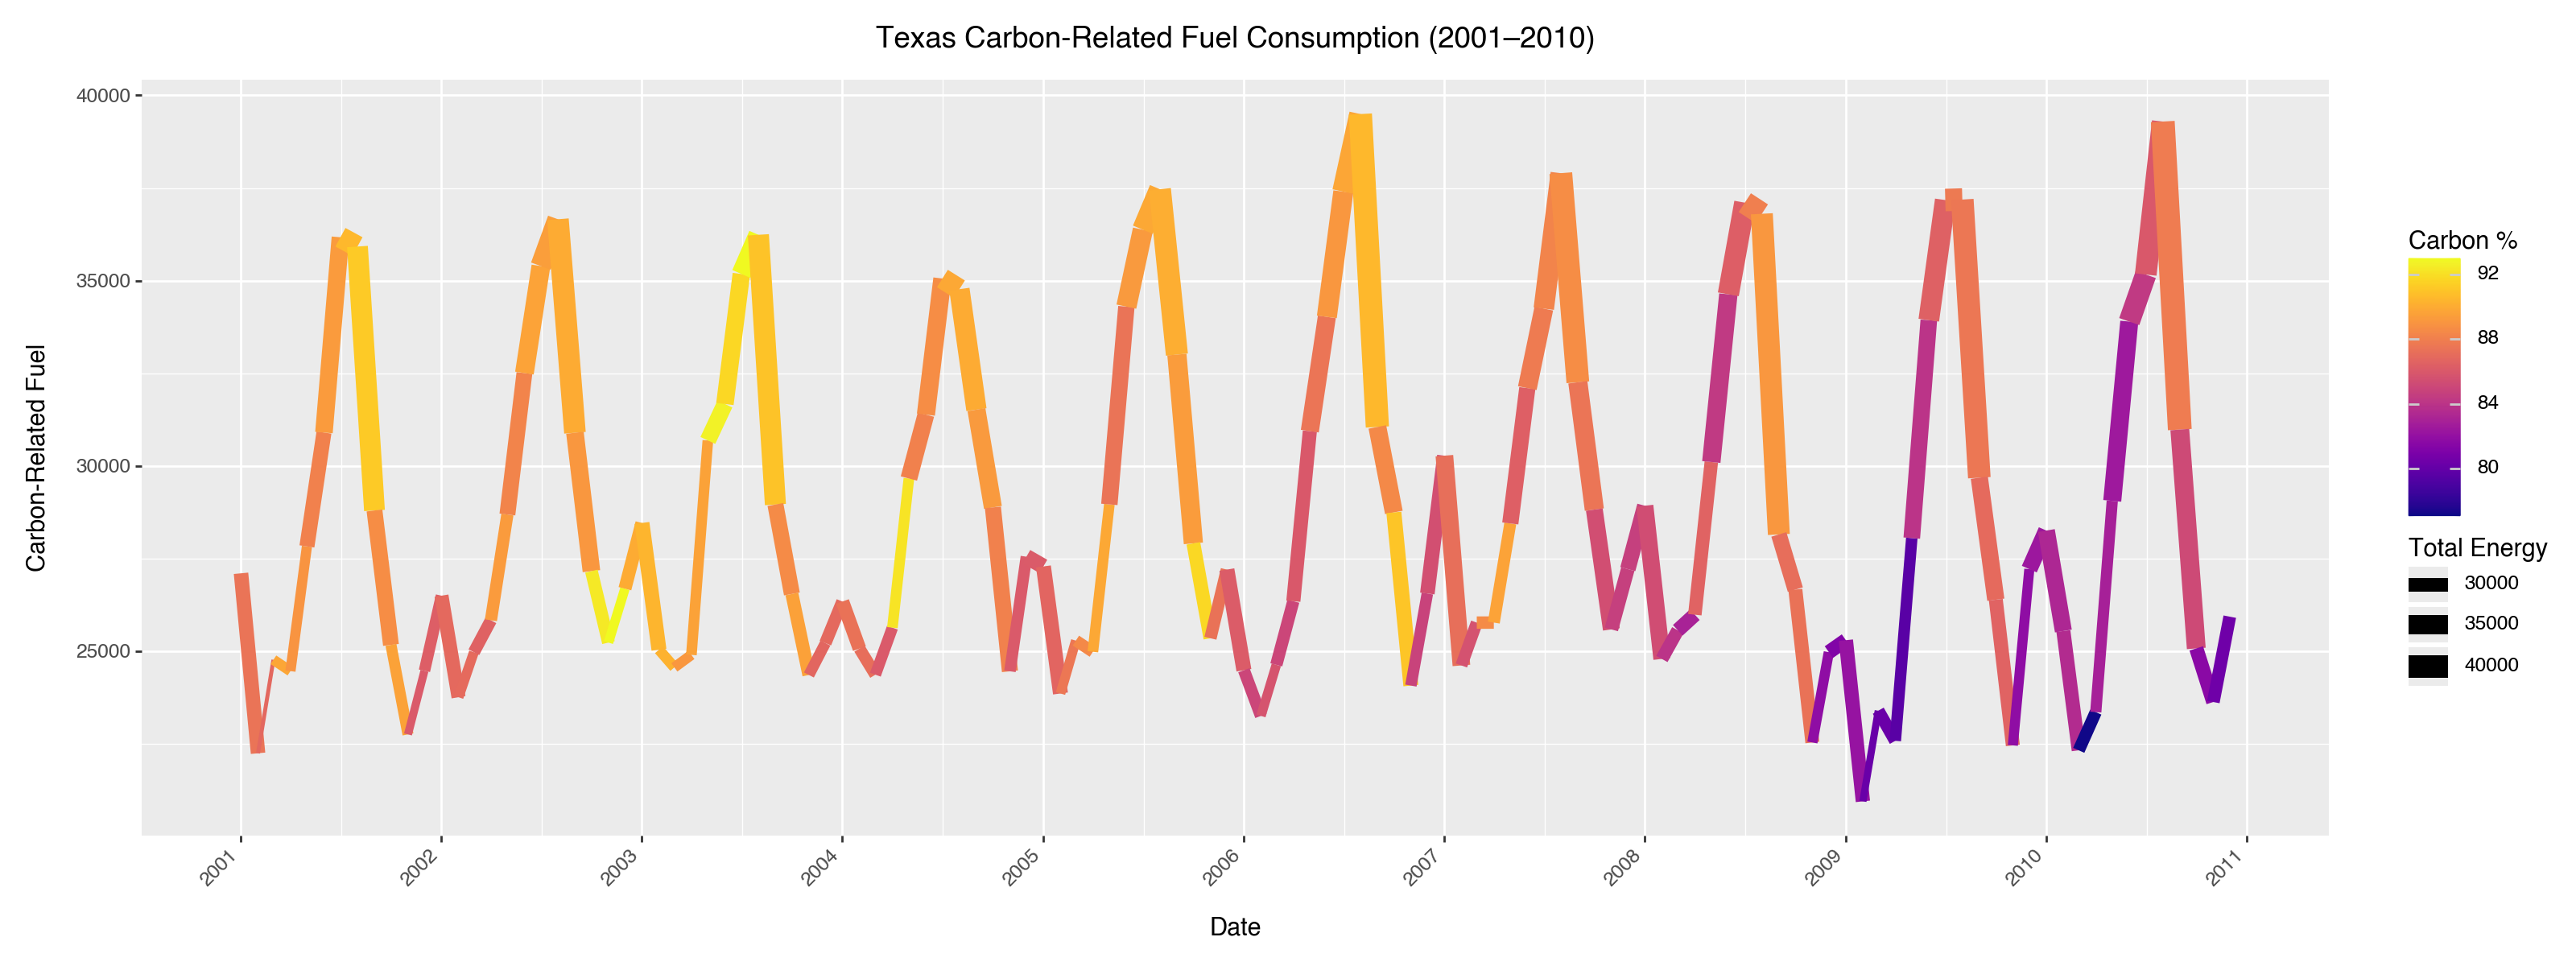

In [28]:
import pandas as pd
import plotnine as p9

# Load data
df = pd.read_csv("TX_fuels_clean1.csv")

# Keep only Texas
df = df[df["STATE"] == "TX"].copy()

# Build variables
df["YEAR"] = df["YEAR"].astype(int)
df["MONTH"] = df["MONTH"].astype(int)
df["Date"] = pd.to_datetime(dict(year=df["YEAR"], month=df["MONTH"], day=1))
df = df.sort_values("Date")

# Add carbon percentage
df["carbon_pct"] = 100 * df["carbon_related_fuel"] / df["Total"]

# Keep 2001-2010
df = df[(df["YEAR"] >= 2001) & (df["YEAR"] <= 2010)].copy()

p = (
    p9.ggplot(
        df,
        p9.aes(
            x="Date",
            y="carbon_related_fuel",
            color="carbon_pct",
            size="Total",
            group=1
        )
    )
    + p9.geom_path()
    + p9.labs(
        title="Texas Carbon-Related Fuel Consumption (2001–2010)",
        x="Date",
        y="Carbon-Related Fuel",
        color="Carbon %",
        size="Total Energy"
    )
    + p9.scale_x_datetime(date_breaks="1 year", date_labels="%Y")
    + p9.scale_color_cmap(
        name="Carbon %",
        cmap_name="plasma",
        limits=(77, 93)
    )
    + p9.theme_gray()
    + p9.theme(
        figure_size=(16, 6),
        axis_text_x=p9.element_text(rotation=45, ha="right")
    )
)

p

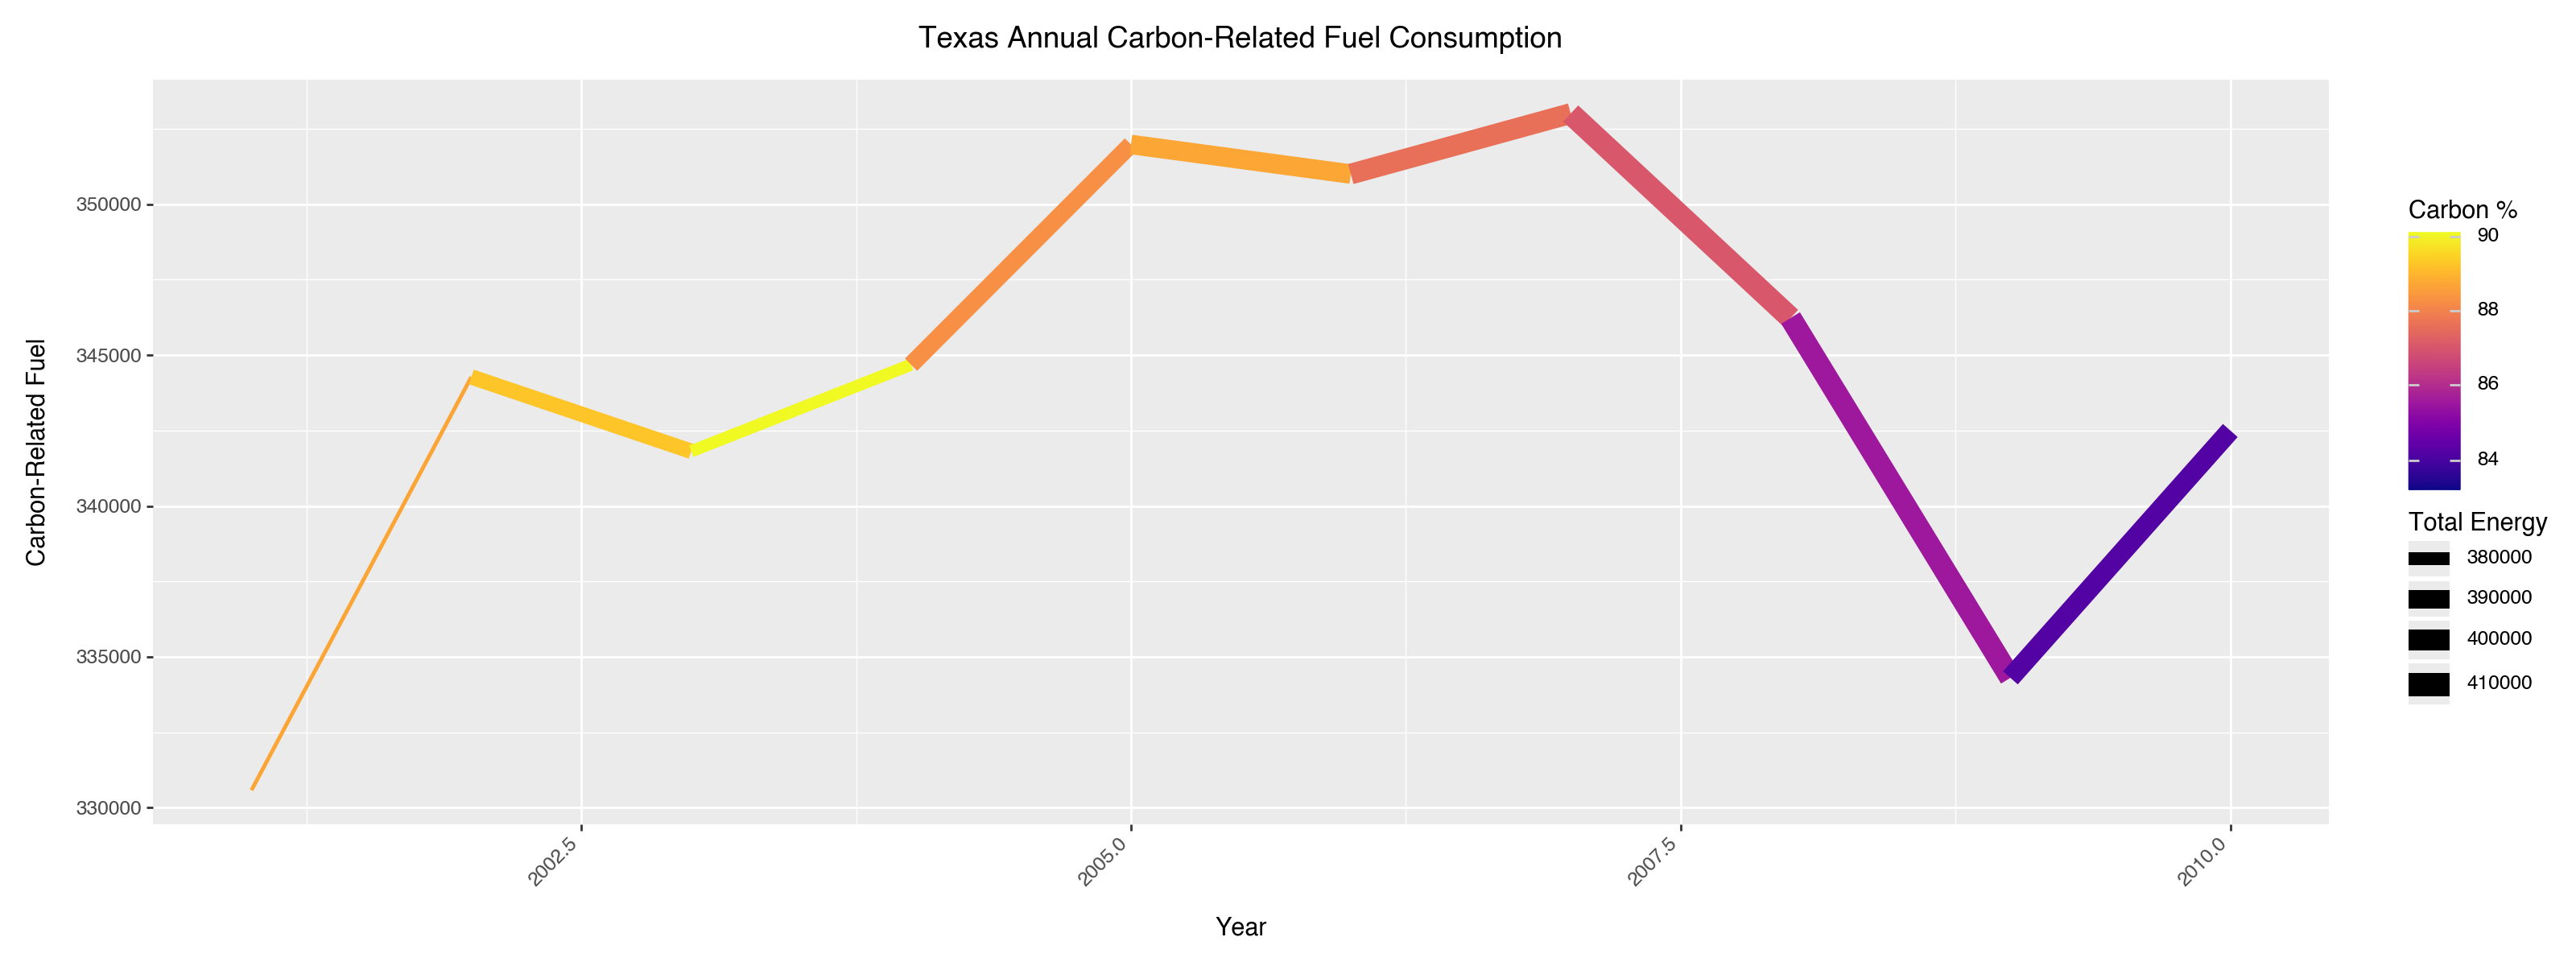

In [32]:
import pandas as pd
import plotnine as p9

# Load annual data
df = pd.read_csv("all_fuels_clean1.csv")

# Keep only Texas
df = df[df["State"] == "TX"].copy()

# Convert year
df["Year"] = df["Year"].astype(int)

# Add carbon percentage
df["carbon_pct"] = 100 * df["carbon_related_fuel"] / df["Total"]

# Sort by year
df = df.sort_values("Year")

p = (
    p9.ggplot(
        df,
        p9.aes(
            x="Year",
            y="carbon_related_fuel",
            color="carbon_pct",
            size="Total",
            group=1
        )
    )
    + p9.geom_path()
    + p9.labs(
        title="Texas Annual Carbon-Related Fuel Consumption",
        x="Year",
        y="Carbon-Related Fuel",
        color="Carbon %",
        size="Total Energy"
    )
    + p9.scale_color_cmap(
        name="Carbon %",
        cmap_name="plasma"
    )
    + p9.theme_gray()
    + p9.theme(
        figure_size=(16, 6),
        axis_text_x=p9.element_text(rotation=45, ha="right")
    )
)

p